# <center> Assignment 1 — Netflix Trends </center>

**Problem Statement:** Examing how the number of titles added to Netflix changed over time (by year). Also observing which countries contribute the most titles over the year.

**Reproducibility rule:** `Kernel → Restart & Run All` should work without errors.

**Workflow:** Imports → Data loading → Checks → Analysis & Visuals → Interpretation.

## Imports
Importing numpy, pandas, and matplotlib

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Data Loading
Loading the dataset

In [2]:
# loading dataset 
DATA_PATH = "../data/netflix_titles.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Dictionary
- **show_id** - unique identifier for each title
- **type** - Movie or TV show
- **title** - name of the show or movie
- **director** - name of the director
- **cast** - names of the actors
- **country** - country where it was made
- **date_added** - the date when the movie was added
- **release_year** - year when it was released
- **rating** - minimum age category to watch the title
- **duration** - runtime of the show or movie
- **listed_in** - genre it is listed in
- **description** - breif overview of what is in the show

## Data Cleaning
Checking if data is clean and cleaning it if it is not

In [3]:
# Checking for Duplicates and removing if any
if df[df.duplicated()].size != 0:
    df = df.drop_duplicates()

In [4]:
# checking number of NAs
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
# fixing datatypes
df["date_added"] = pd.to_datetime(df["date_added"])
df["release_year"] = df["release_year"].astype(int)

In [6]:
# checking if type column has only Movie and TV show as values
df["type"].value_counts()

Movie      6131
TV Show    2676
Name: type, dtype: int64

### Data Checks

In [7]:
# Checking shape of data
df.shape

(8807, 12)

In [8]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


# <center>Analysis & Visuals</center>

## Identifying Outliers
Checking to see what durations of movies are shorter or longer than usual

In [9]:
# grouping movies
movies = df[df["type"] == "Movie"]

In [10]:
# dropping movies with NA as duration
movies = movies.dropna(subset ="duration")

In [11]:
# Converting movie duration from string to float
movies["duration"] = movies["duration"].str.extract(r"(\d+)").astype(float)

In [12]:
# making a numpy array for movies
movieDuration = movies["duration"].to_numpy()
movieDuration

array([ 90.,  91., 125., ...,  88.,  88., 111.])

In [13]:
# function to find outliers by taking the lowest 10% and highest 10% of the values
def find_outliers(arr):
    lowerBound = np.percentile(arr, 10)
    upperBound = np.percentile(arr, 90)

    outliers = (arr < lowerBound) | (arr > upperBound)

    return outliers

In [14]:
# calling function and printing the outliers out
outliers = find_outliers(movieDuration)

movies[outliers]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
22,s23,Movie,Avvai Shanmughi,K.S. Ravikumar,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",NaN,2021-09-21,1996,TV-PG,161.0,"Comedies, International Movies",Newly divorced and denied visitation rights wi...
23,s24,Movie,Go! Go! Cory Carson: Chrissy Takes the Wheel,"Alex Woo, Stanley Moore","Maisie Benson, Paul Killam, Kerry Gudjohnsen, ...",NaN,2021-09-21,2021,TV-Y,61.0,Children & Family Movies,From arcade games to sled days and hiccup cure...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,2021-09-21,1998,TV-14,166.0,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
26,s27,Movie,Minsara Kanavu,Rajiv Menon,"Arvind Swamy, Kajol, Prabhu Deva, Nassar, S.P....",NaN,2021-09-21,1997,TV-PG,147.0,"Comedies, International Movies, Music & Musicals",A tangled love triangle ensues when a man fall...
45,s46,Movie,My Heroes Were Cowboys,Tyler Greco,NaN,NaN,2021-09-16,2021,PG,23.0,Documentaries,Robin Wiltshire's painful childhood was rescue...
...,...,...,...,...,...,...,...,...,...,...,...,...
8770,s8771,Movie,Yaadein,Subhash Ghai,"Jackie Shroff, Hrithik Roshan, Kareena Kapoor,...",India,2018-03-01,2001,TV-14,171.0,"Dramas, International Movies, Romantic Movies",Two young lovers set out to overcome the obsta...
8772,s8773,Movie,Yamla Pagla Deewana 2,Sangeeth Sivan,"Dharmendra, Sunny Deol, Bobby Deol, Neha Sharm...",India,2017-05-01,2013,TV-14,147.0,"Action & Adventure, Comedies, International Mo...","Up to his old tricks, con man Dharam poses as ..."
8773,s8774,Movie,Yanda Kartavya Aahe,Kedar Shinde,"Ankush Choudhary, Smita Shewale, Mohan Joshi, ...",India,2018-01-01,2006,TV-PG,151.0,"Comedies, Dramas, International Movies",Thanks to an arranged marriage that was design...
8788,s8789,Movie,You Carry Me,Ivona Juka,"Lana Baric, Vojislav Brajovic, Natasa Janjic, ...","Croatia, Slovenia, Serbia, Montenegro",2016-07-01,2015,TV-MA,157.0,"Dramas, International Movies","A soap opera producer, director and makeup art..."


## Comparison of TV shows and Movies added to Netflix per year
Comparing the number of TV shows to the number of Movies added to Netflix each year

In [15]:
# takes the dataframe as input and returns a table showing how many Movies, TV Shows, and total titles were added to Netflix each year.

def titles_added_per_year(dataframe):
    dataframe["year_added"] = dataframe["date_added"].dt.year
    summary = (
        dataframe
        .dropna(subset=["year_added"])   # dropping NA in year_added column
        .groupby(["year_added", "type"])   # grouping by year_added
        .size()
        .unstack(fill_value=0)
    )

    summary["Total"] = summary.sum(axis=1) # adding total released

    return summary

In [16]:
# Calling function and printing out table
titlesAddedPerYear = titles_added_per_year(df)
titlesAddedPerYear

type,Movie,TV Show,Total
year_added,,,
2008.0,1,1,2
2009.0,2,0,2
2010.0,1,0,1
2011.0,13,0,13
2012.0,3,0,3
2013.0,6,5,11
2014.0,19,5,24
2015.0,56,26,82
2016.0,253,176,429


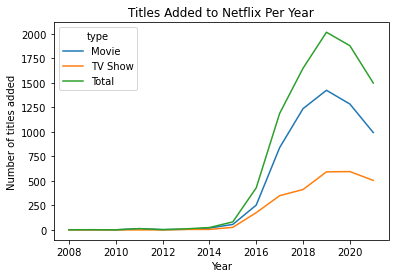

In [17]:
# Plotting a line graph for the number of titles added to Netflix per year
titlesAddedPerYear.plot()
plt.xlabel("Year")
plt.ylabel("Number of titles added")
plt.title("Titles Added to Netflix Per Year")
plt.show()

##### **Plot Description:**
This plot shows the number of Titles added to Netflix each year while also showing a comparison between Movies and TV shows added. In the beginning, they are adding titles at a steady rate, however, in 2016 there is a huge leap in the number and this trend continues. The number of TV shows added show an upwards trend but are significantly lower in number than the movies added at the same time. In 2019, both hit their peak and the number of titles added are slowly decreasing with movies dropping more in number than TV shows.

## Finding out which Country contributes the most titles to Netflix
Grouping data by country and finding out which country has the most number of Netflix titles.

In [18]:
# Returns a table with the number of Movies, TV Shows, and total titles grouped together by country.
def titles_by_country(dataframe):
    countryRows = (
        dataframe
        .dropna(subset=["country"])
        .assign(country=dataframe["country"].str.split(", "))
        .explode("country")
    )

    summary = (
        countryRows
        .groupby(["country", "type"])
        .size()
        .unstack(fill_value=0)
    )

    summary["Total"] = summary.sum(axis=1)

    return summary.sort_values("Total", ascending=False)

In [19]:
country_summary = titles_by_country(df)
country_summary

type,Movie,TV Show,Total
country,,,
United States,2751,938,3689
India,962,84,1046
United Kingdom,532,272,804
Canada,319,126,445
France,303,90,393
...,...,...,...
Kazakhstan,1,0,1
Jamaica,1,0,1
Slovakia,1,0,1


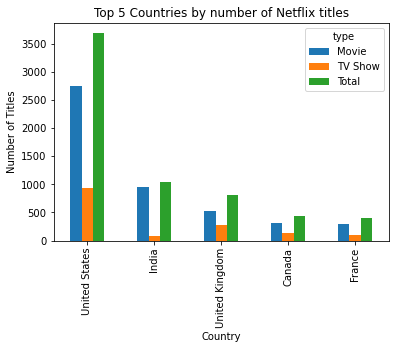

In [20]:
# Plotting a bar graph for the top 5 countries with the most Netflix titles
country_summary.head().plot.bar()
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.title("Top 5 Countries by number of Netflix titles")
plt.show()

##### **Plot Description:**
This bar graph shows the number of titles added by the top 5 countries. United States leads the chart with the most titles of all time and almost as many TV Shows as the next country has Movies. Overall each country has fewer TV shows than movies. The top 5 countries are United States, India, United Kingdom, Canada, and France.

# <center>Interpretations</center>

### Q- How has the number of titles added to Netflix changed over time (by year)?

Ans- The number of titles added to Netflix were on a slow rise upto 2016, where it started to plummet and peaked in 2019. After 2019 the number of titles added are on a slow decline.

### Q- Which countries contribute the most titles?

Ans- The top 5 countries which contributed to the most titles on Netflix are the United States, India, United Kingdom, Canada, and France.